# NAFNet SISR v3 — Grouped Tuning + Fast Iteration

v2 plateaued at ~27 dB (blur ceiling, not overfitting). v3 gives you the levers to
break through, organized so you change **coordinated groups** and test each with a
short probe run before committing to a full run.

## The one config cell (Cell 0)
Everything you tune lives in `CFG`. Change a **group**, run a probe, keep the winner.

**Groups (change together, in this order):**
- **A — Loss rebalance** (`use_gan`, `lpips_w`, `grad_w`, `gan_w`, `fft_w`). Cheapest,
  highest payoff. Fights blur directly.
- **B — Residual head** (`residual`, `head_extra`). Predict detail over a bilinear
  upsample. ~0.5-1 dB, small cost.
- **C — Capacity** (`width`, `mid_blocks`, `stage_blocks`). Expensive; only if A+B stall.
- **D — Data/aug** (`lr_crop`, `rotations`, `intensity_jitter`, `renormalize`).
  Orthogonal to A-C.
- **E — Hygiene** (`use_ema`, `lr`, `weight_decay`, `grad_clip`). Cheap; add EMA to
  the winner last.

## Fast iteration
- `CFG['quick']=True` -> trains on a **subset** for **few epochs** (probe mode).
  Relative ranking between configs holds; use it to pick winners. Set `False` for the
  final run.
- **Early stopping** on a smoothed val-PSNR with a min-epoch floor (rides out the
  early jumpiness seen in v2's curve). Paired with **ReduceLROnPlateau** so the
  scheduler doesn't fight it.
- Set `num_workers>0` so data loading doesn't starve the GPU.

**Metric caveat:** turning on GAN/perceptual/FFT makes images sharper but can lower
PSNR. Track both; that trade is expected and usually the better submission.

In [1]:
# Cell 0: ONE config to rule them all. Change groups here.
CFG = {
    # ---- iteration mode ----
    'quick': False,         # True = probe (subset + few epochs). False = full run.
    'quick_frac': 0.25,     # fraction of train data used in probe mode
    'quick_epochs': 12,     # epoch ceiling in probe mode
    'full_epochs': 60,      # epoch ceiling in full mode (early stopping ends it sooner)

    # ---- early stopping ----
    'es_patience': 15,       # stop after this many epochs w/o meaningful gain
    'es_min_delta': 0.03,   # dB; gains smaller than this don't count
    'es_min_epochs': 12,    # never stop before this (probe mode auto-shrinks this)

    # ---- Group A: loss rebalance ----
    'use_gan':   True ,# <-- turn True for texture synthesis (biggest lever)
    'lpips_w':   0.8,
    'grad_w':    0.2,
    'gan_w':     0.05,
    'fft_w':     0.05,       # frequency-domain loss; try 0.05-0.1 for high-freq detail

    # ---- Group B: residual head ----
    'residual':   True,     # predict GT - bilinear(input); learn only the detail
    'head_extra': True,     # deeper reconstruction tail

    # ---- Group C: capacity ----
    'width':        64,
    'mid_blocks':   6,
    'stage_blocks': 3,

    # ---- Group D: data / augmentation ----
    'lr_crop':          96,
    'rotations':        True,   # random 90/180/270 (free 4x for this imagery)
    'intensity_jitter': True,   # small brightness/contrast jitter on input
    'renormalize':      False,  # standardize input (deck invites re-normalization)

    # ---- Group E: hygiene ----
    'use_ema':      True,
    'lr':           1e-3,
    'weight_decay': 1e-4,
    'grad_clip':    1.0,
    'batch_size':   16,
    'num_workers':  0,      # >0 so loading doesn't starve the GPU
    'scale':        2,
}

# Derived
CFG['epochs'] = CFG['quick_epochs'] if CFG['quick'] else CFG['full_epochs']
CFG['es_min_epochs'] = min(CFG['es_min_epochs'], max(4, CFG['epochs'] // 2))
import json as _json
print("Active config:\n" + _json.dumps(CFG, indent=2))

Active config:
{
  "quick": false,
  "quick_frac": 0.25,
  "quick_epochs": 12,
  "full_epochs": 60,
  "es_patience": 6,
  "es_min_delta": 0.03,
  "es_min_epochs": 12,
  "use_gan": true,
  "lpips_w": 0.8,
  "grad_w": 0.2,
  "gan_w": 0.05,
  "fft_w": 0.05,
  "residual": true,
  "head_extra": true,
  "width": 64,
  "mid_blocks": 6,
  "stage_blocks": 3,
  "lr_crop": 96,
  "rotations": true,
  "intensity_jitter": true,
  "renormalize": false,
  "use_ema": true,
  "lr": 0.001,
  "weight_decay": 0.0001,
  "grad_clip": 1.0,
  "batch_size": 16,
  "num_workers": 0,
  "scale": 2,
  "epochs": 60
}


In [2]:
# Cell 1: Imports & Setup
import os, glob, random, copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure
import lpips

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using compute device: {device}")

Using compute device: cuda


In [3]:
# Cell 2: Dataset, Augmentation, Split
class KLAHackathonDataset(Dataset):
    def __init__(self, gt_paths, noisy_paths, cfg, train=True):
        self.gt_paths = list(gt_paths); self.noisy_paths = list(noisy_paths)
        self.cfg = cfg; self.train = train
        self.lr_crop = cfg['lr_crop']; self.scale = cfg['scale']
        if not self.gt_paths or not self.noisy_paths:
            raise RuntimeError("Empty file list.")
        assert len(self.gt_paths) == len(self.noisy_paths)
        print(f"Loaded {len(self.gt_paths)} pairs for {'Train' if train else 'Val'}.")

    def __len__(self):
        return len(self.gt_paths)

    def _rng(self, idx):
        base = torch.initial_seed() % (2**31 - 1)
        return np.random.default_rng(base + idx)

    def __getitem__(self, idx):
        gt = np.load(self.gt_paths[idx]).astype(np.float32)
        noisy = np.load(self.noisy_paths[idx]).astype(np.float32)
        h_lr, w_lr = noisy.shape; h_gt, w_gt = gt.shape
        assert h_gt % h_lr == 0 and w_gt % w_lr == 0, \
            f"GT {gt.shape} not multiple of LR {noisy.shape}"
        s = h_gt // h_lr
        assert (w_gt // w_lr) == s == self.scale, "scale mismatch"

        if self.train:
            rng = self._rng(idx); cs = self.lr_crop
            if h_lr > cs and w_lr > cs:
                x = int(rng.integers(0, w_lr - cs + 1)); y = int(rng.integers(0, h_lr - cs + 1))
                noisy = noisy[y:y+cs, x:x+cs]; gt = gt[y*s:(y+cs)*s, x*s:(x+cs)*s]
            if rng.random() > 0.5:
                noisy = np.fliplr(noisy).copy(); gt = np.fliplr(gt).copy()
            if rng.random() > 0.5:
                noisy = np.flipud(noisy).copy(); gt = np.flipud(gt).copy()
            if self.cfg['rotations']:
                k = int(rng.integers(0, 4))
                if k:
                    noisy = np.rot90(noisy, k).copy(); gt = np.rot90(gt, k).copy()
            if rng.random() > 0.5:
                sig = float(rng.uniform(0.01, 0.05))
                noisy = noisy + noisy * rng.normal(0.0, sig, noisy.shape).astype(np.float32)
            if self.cfg['intensity_jitter'] and rng.random() > 0.5:
                gain = float(rng.uniform(0.9, 1.1)); bias = float(rng.uniform(-0.03, 0.03))
                noisy = noisy * gain + bias   # input only; GT stays the target

        if self.cfg['renormalize']:
            m, sd = float(noisy.mean()), float(noisy.std() + 1e-6)
            noisy = (noisy - m) / sd   # NOTE: model then learns to map to GT's [0,1]

        gt_t = torch.from_numpy(np.ascontiguousarray(gt)).unsqueeze(0)
        noisy_t = torch.from_numpy(np.ascontiguousarray(noisy)).unsqueeze(0)
        return noisy_t, gt_t


gt_dir = 'data/train/train/GT'; noisy_dir = 'data/train/train/NoisyLR'
all_gt = sorted(glob.glob(os.path.join(gt_dir, '*.npy')))
all_noisy = sorted(glob.glob(os.path.join(noisy_dir, '*.npy')))
assert len(all_gt) == len(all_noisy) and len(all_gt) > 0, "No matching images!"

pairs = list(zip(all_gt, all_noisy))
random.seed(SEED); random.shuffle(pairs)
sgt, sno = zip(*pairs)
split = int(0.9 * len(sgt))
train_gt, train_no = list(sgt[:split]), list(sno[:split])
val_gt, val_no = list(sgt[split:]), list(sno[split:])

# Probe mode: subsample the TRAIN set only (val stays fixed for fair comparison)
if CFG['quick']:
    n_keep = max(1, int(CFG['quick_frac'] * len(train_gt)))
    train_gt, train_no = train_gt[:n_keep], train_no[:n_keep]
    print(f"[QUICK] Training on subset: {n_keep} pairs")

train_dataset = KLAHackathonDataset(train_gt, train_no, CFG, train=True)
val_dataset = KLAHackathonDataset(val_gt, val_no, CFG, train=False)
train_loader = DataLoader(train_dataset, batch_size=CFG['batch_size'], shuffle=True,
                          num_workers=CFG['num_workers'], pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)

Loaded 2880 pairs for Train.
Loaded 320 pairs for Val.


In [4]:
# Cell 3: NAFNet (residual head optional, capacity from CFG)
class LayerNorm2d(nn.Module):
    def __init__(self, c):
        super().__init__(); self.norm = nn.LayerNorm(c)
    def forward(self, x):
        x = x.permute(0,2,3,1); x = self.norm(x); return x.permute(0,3,1,2)

class SimpleGate(nn.Module):
    def forward(self, x):
        a, b = x.chunk(2, dim=1); return a * b

class SCA(nn.Module):
    def __init__(self, c):
        super().__init__(); self.pool = nn.AdaptiveAvgPool2d(1); self.conv = nn.Conv2d(c, c, 1)
    def forward(self, x):
        return x * self.conv(self.pool(x))

class NAFBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.ln1 = LayerNorm2d(c); self.conv1 = nn.Conv2d(c, c*2, 1)
        self.dw = nn.Conv2d(c*2, c*2, 3, 1, 1, groups=c*2)
        self.sg1 = SimpleGate(); self.sca = SCA(c); self.conv2 = nn.Conv2d(c, c, 1)
        self.ln2 = LayerNorm2d(c); self.conv3 = nn.Conv2d(c, c*2, 1)
        self.sg2 = SimpleGate(); self.conv4 = nn.Conv2d(c, c, 1)
    def forward(self, x):
        out = self.conv2(self.sca(self.sg1(self.dw(self.conv1(self.ln1(x))))))
        x = x + out; res = x
        out = self.conv4(self.sg2(self.conv3(self.ln2(x))))
        return out + res

def stage(c, n):
    return nn.Sequential(*[NAFBlock(c) for _ in range(n)])

class NAFNet_SISR(nn.Module):
    def __init__(self, cfg, in_ch=1):
        super().__init__()
        w = cfg['width']; nb = cfg['stage_blocks']; mb = cfg['mid_blocks']
        self.residual = cfg['residual']; self.scale = cfg['scale']
        self.intro = nn.Conv2d(in_ch, w, 3, 1, 1)
        self.enc1 = stage(w, nb); self.down1 = nn.Conv2d(w, w*2, 2, 2)
        self.enc2 = stage(w*2, nb); self.down2 = nn.Conv2d(w*2, w*4, 2, 2)
        self.mid = stage(w*4, mb)
        self.up1 = nn.Sequential(nn.Conv2d(w*4, w*8, 1), nn.PixelShuffle(2)); self.dec1 = stage(w*2, nb)
        self.up2 = nn.Sequential(nn.Conv2d(w*2, w*4, 1), nn.PixelShuffle(2)); self.dec2 = stage(w, nb)
        if cfg['head_extra']:
            self.sr_head = nn.Sequential(
                nn.Conv2d(w, w*4, 3, 1, 1), nn.PixelShuffle(2),
                nn.Conv2d(w, w, 3, 1, 1), nn.GELU(),
                nn.Conv2d(w, w, 3, 1, 1), nn.GELU(),
                nn.Conv2d(w, 1, 3, 1, 1))
        else:
            self.sr_head = nn.Sequential(
                nn.Conv2d(w, w*4, 3, 1, 1), nn.PixelShuffle(2),
                nn.Conv2d(w, 1, 3, 1, 1))
    def forward(self, x):
        base = F.interpolate(x, scale_factor=self.scale, mode='bilinear', align_corners=False)
        f = self.intro(x)
        e1 = self.enc1(f); e2 = self.enc2(self.down1(e1)); m = self.mid(self.down2(e2))
        u1 = self.dec1(self.up1(m) + e2); u2 = self.dec2(self.up2(u1) + e1)
        out = self.sr_head(u2)
        return base + out if self.residual else out

model = NAFNet_SISR(CFG).to(device)
print(f"Generator params: {sum(p.numel() for p in model.parameters())/1e6:.2f}M "
      f"| residual={CFG['residual']}")

Generator params: 4.25M | residual=True


In [5]:
# Cell 4: Losses, optional GAN, EMA, Metrics
def charbonnier(pred, target, eps=1e-3):
    return torch.sqrt((pred - target)**2 + eps**2).mean()

def gradient_loss(pred, target):
    px = pred[..., :, 1:] - pred[..., :, :-1]; py = pred[..., 1:, :] - pred[..., :-1, :]
    tx = target[..., :, 1:] - target[..., :, :-1]; ty = target[..., 1:, :] - target[..., :-1, :]
    return (px - tx).abs().mean() + (py - ty).abs().mean()

def fft_loss(pred, target):
    # penalize magnitude-spectrum difference -> targets missing high frequencies
    pf = torch.fft.rfft2(pred, norm='ortho'); tf = torch.fft.rfft2(target, norm='ortho')
    return (pf.abs() - tf.abs()).abs().mean()

class RestorationLoss(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.lpips_loss = lpips.LPIPS(net='vgg').to(device)
        for p in self.lpips_loss.parameters():
            p.requires_grad_(False)
    def forward(self, pred, target):
        pix = charbonnier(pred, target)
        grad = gradient_loss(pred, target)
        pred_in = pred.clamp(0, 1)
        perc = self.lpips_loss((pred_in.repeat(1,3,1,1)*2)-1,
                               (target.clamp(0,1).repeat(1,3,1,1)*2)-1).mean()
        total = pix + self.cfg['lpips_w']*perc + self.cfg['grad_w']*grad
        parts = {'pixel': pix.item(), 'lpips': perc.item(), 'grad': grad.item(), 'fft': 0.0}
        if self.cfg['fft_w'] > 0:
            ff = fft_loss(pred, target)
            total = total + self.cfg['fft_w']*ff; parts['fft'] = ff.item()
        return total, parts

criterion = RestorationLoss(CFG)
optimizer = optim.AdamW(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])

class PatchDiscriminator(nn.Module):
    def __init__(self, in_ch=1, base=64):
        super().__init__()
        def blk(i, o, s, norm=True):
            layers = [nn.Conv2d(i, o, 4, s, 1)]
            if norm: layers.append(nn.InstanceNorm2d(o))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return nn.Sequential(*layers)
        self.net = nn.Sequential(
            blk(in_ch, base, 2, norm=False), blk(base, base*2, 2),
            blk(base*2, base*4, 2), blk(base*4, base*4, 1),
            nn.Conv2d(base*4, 1, 4, 1, 1))
    def forward(self, x):
        return self.net(x)

if CFG['use_gan']:
    discriminator = PatchDiscriminator().to(device)
    optimizer_d = optim.AdamW(discriminator.parameters(), lr=1e-4, weight_decay=CFG['weight_decay'])
    bce = nn.BCEWithLogitsLoss()
    print(f"Discriminator params: {sum(p.numel() for p in discriminator.parameters())/1e6:.2f}M")
else:
    discriminator = None

# ---- Exponential Moving Average of weights (Group E) ----
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = copy.deepcopy(model).eval()
        for p in self.shadow.parameters():
            p.requires_grad_(False)
    @torch.no_grad()
    def update(self, model):
        for s, m in zip(self.shadow.parameters(), model.parameters()):
            s.mul_(self.decay).add_(m, alpha=1 - self.decay)
        for s, m in zip(self.shadow.buffers(), model.buffers()):
            s.copy_(m)

ema = EMA(model) if CFG['use_ema'] else None

psnr_calc = PeakSignalNoiseRatio(data_range=1.0).to(device)
ssim_calc = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


C:\Users\harry\anaconda3\envs\ml_workspace\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\harry\anaconda3\envs\ml_workspace\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: C:\Users\harry\anaconda3\envs\ml_workspace\lib\site-packages\lpips\weights\v0.1\vgg.pth
Discriminator params: 1.71M


In [6]:
# Cell 5: Training — early stopping + ReduceLROnPlateau
EPOCHS = CFG['epochs']
CKPT_PATH = 'nafnet_sisr_v3_best.pth'
history = {'train_loss': [], 'val_loss': [], 'val_psnr': [], 'val_ssim': [],
           'pixel': [], 'lpips': [], 'grad': [], 'fft': [], 'g_adv': [], 'd_loss': []}

# ReduceLROnPlateau pairs naturally with early stopping (drops LR when val stalls),
# unlike cosine which assumes a fixed horizon.
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max',
                                                 factor=0.5, patience=3)

best_psnr = -float('inf'); epochs_no_improve = 0
psnr_smooth = None; SMOOTH = 0.6   # EMA-smoothed val PSNR for stable early-stop decisions

def eval_model(eval_net):
    eval_net.eval(); vsum = psum = ssum = 0.0
    with torch.no_grad():
        for noisy, gt in val_loader:
            noisy = noisy.to(device).float(); gt = gt.to(device).float()
            pred = eval_net(noisy); vloss, _ = criterion(pred, gt)
            pc = torch.clamp(pred, 0, 1)
            vsum += vloss.item(); psum += psnr_calc(pc, gt).item(); ssum += ssim_calc(pc, gt).item()
    n = len(val_loader); return vsum/n, psum/n, ssum/n

for epoch in range(EPOCHS):
    model.train()
    ep = {k: 0.0 for k in ['loss','pixel','lpips','grad','fft','g_adv','d_loss']}
    for noisy, gt in train_loader:
        noisy = noisy.to(device, non_blocking=True).float()
        gt = gt.to(device, non_blocking=True).float()

        if CFG['use_gan']:
            with torch.no_grad():
                fake = model(noisy).clamp(0, 1)
            optimizer_d.zero_grad()
            d_real = discriminator(gt.clamp(0, 1)); d_fake = discriminator(fake)
            d_loss = 0.5*(bce(d_real, torch.ones_like(d_real)) + bce(d_fake, torch.zeros_like(d_fake)))
            d_loss.backward(); optimizer_d.step(); ep['d_loss'] += d_loss.item()

        optimizer.zero_grad()
        pred = model(noisy)
        loss, parts = criterion(pred, gt)
        if CFG['use_gan']:
            g_fake = discriminator(pred.clamp(0, 1))
            g_adv = bce(g_fake, torch.ones_like(g_fake))
            loss = loss + CFG['gan_w']*g_adv; ep['g_adv'] += g_adv.item()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
        optimizer.step()
        if ema: ema.update(model)
        ep['loss'] += loss.item()
        for k in ['pixel','lpips','grad','fft']:
            ep[k] += parts[k]

    n = len(train_loader)
    for k in ['loss','pixel','lpips','grad','fft','g_adv','d_loss']:
        history[k if k != 'loss' else 'train_loss'].append(ep[k]/n)

    eval_net = ema.shadow if ema else model
    avg_val, avg_psnr, avg_ssim = eval_model(eval_net)
    history['val_loss'].append(avg_val); history['val_psnr'].append(avg_psnr); history['val_ssim'].append(avg_ssim)

    scheduler.step(avg_psnr)
    psnr_smooth = avg_psnr if psnr_smooth is None else SMOOTH*psnr_smooth + (1-SMOOTH)*avg_psnr

    improved = avg_psnr > best_psnr + CFG['es_min_delta']
    if improved:
        best_psnr = avg_psnr; epochs_no_improve = 0
        torch.save((ema.shadow if ema else model).state_dict(), CKPT_PATH); tag = "  <-- best"
    else:
        epochs_no_improve += 1; tag = ""

    lr_now = optimizer.param_groups[0]['lr']
    extra = f" | D {history['d_loss'][-1]:.3f}" if CFG['use_gan'] else ""
    print(f"E[{epoch+1:02d}/{EPOCHS}] Train {history['train_loss'][-1]:.4f} "
          f"(pix {history['pixel'][-1]:.4f} lpips {history['lpips'][-1]:.4f} "
          f"grad {history['grad'][-1]:.4f} fft {history['fft'][-1]:.4f}) "
          f"| Val {avg_val:.4f} PSNR {avg_psnr:.2f}(sm {psnr_smooth:.2f}) SSIM {avg_ssim:.4f} "
          f"| lr {lr_now:.1e}{extra}{tag}")

    if (epoch + 1) >= CFG['es_min_epochs'] and epochs_no_improve >= CFG['es_patience']:
        print(f"\nEarly stopping at epoch {epoch+1} (best PSNR {best_psnr:.2f} dB, "
              f"no gain > {CFG['es_min_delta']} for {CFG['es_patience']} epochs)")
        break

model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
print(f"\nRestored best {'(EMA) ' if ema else ''}model: Val PSNR {best_psnr:.2f} dB")

E[01/60] Train 0.4416 (pix 0.0479 lpips 0.4149 grad 0.0833 fft 0.0266) | Val 0.4404 PSNR 24.14(sm 24.14) SSIM 0.5465 | lr 1.0e-03 | D 0.615  <-- best
E[02/60] Train 0.4107 (pix 0.0444 lpips 0.3831 grad 0.0772 fft 0.0239) | Val 0.4325 PSNR 24.56(sm 24.31) SSIM 0.5730 | lr 1.0e-03 | D 0.634  <-- best
E[03/60] Train 0.3943 (pix 0.0436 lpips 0.3650 grad 0.0765 fft 0.0230) | Val 0.4156 PSNR 24.96(sm 24.57) SSIM 0.5954 | lr 1.0e-03 | D 0.640  <-- best
E[04/60] Train 0.3823 (pix 0.0432 lpips 0.3512 grad 0.0758 fft 0.0225) | Val 0.4066 PSNR 25.31(sm 24.86) SSIM 0.6117 | lr 1.0e-03 | D 0.644  <-- best
E[05/60] Train 0.3739 (pix 0.0429 lpips 0.3422 grad 0.0754 fft 0.0220) | Val 0.3998 PSNR 25.66(sm 25.18) SSIM 0.6251 | lr 1.0e-03 | D 0.649  <-- best
E[06/60] Train 0.3644 (pix 0.0424 lpips 0.3317 grad 0.0747 fft 0.0216) | Val 0.3922 PSNR 25.95(sm 25.49) SSIM 0.6379 | lr 1.0e-03 | D 0.654  <-- best
E[07/60] Train 0.3602 (pix 0.0421 lpips 0.3269 grad 0.0746 fft 0.0215) | Val 0.3832 PSNR 26.23(sm 25

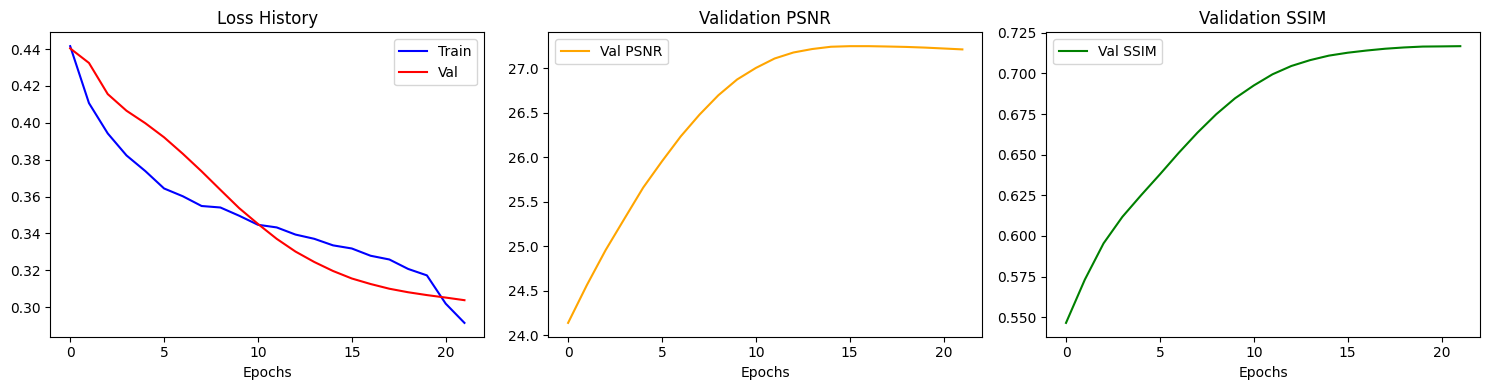

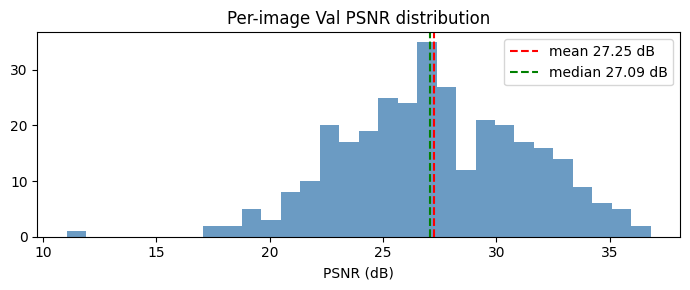

PSNR: mean 27.25 | median 27.09 | p10 22.22 | p90 32.72


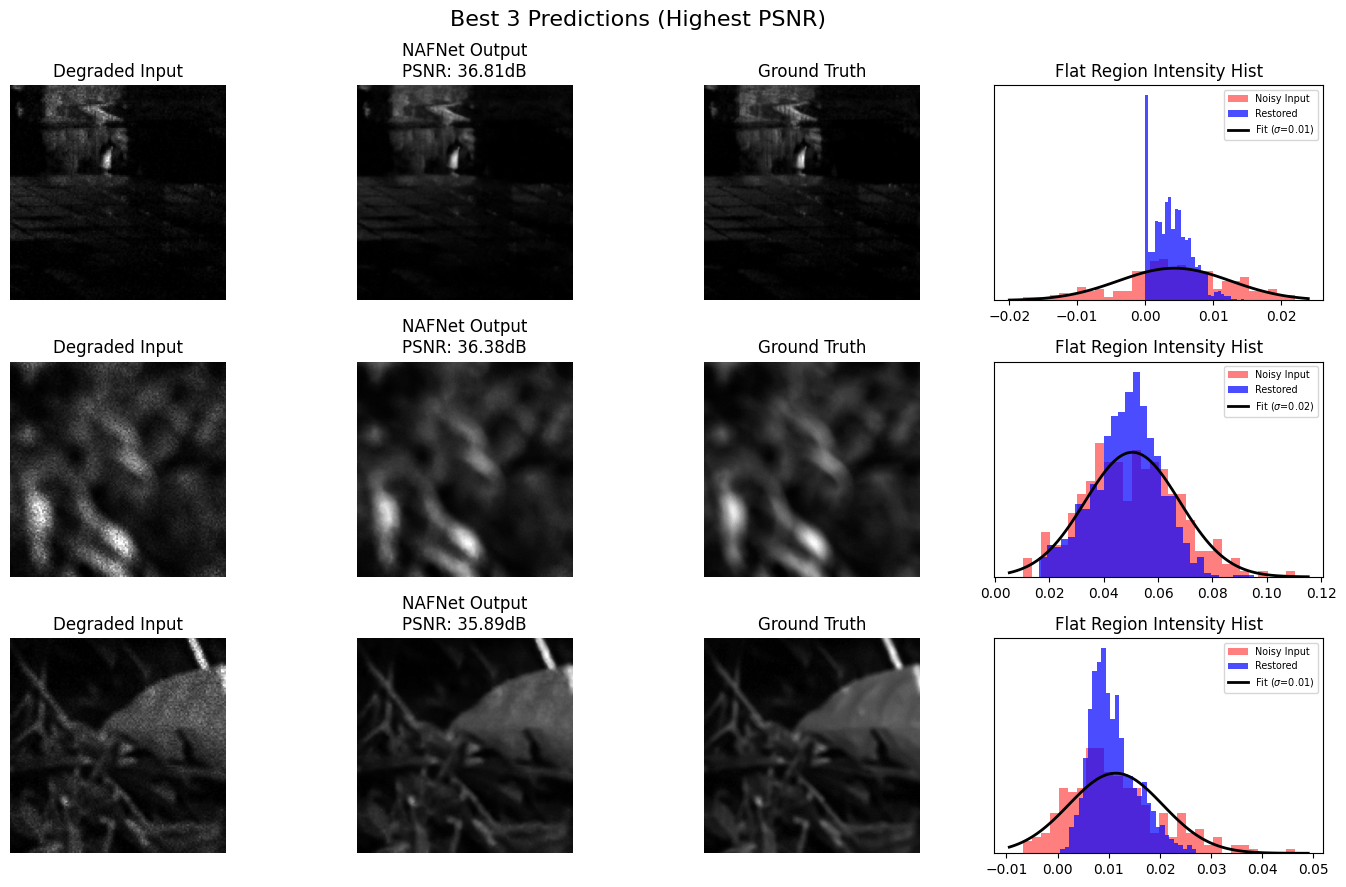

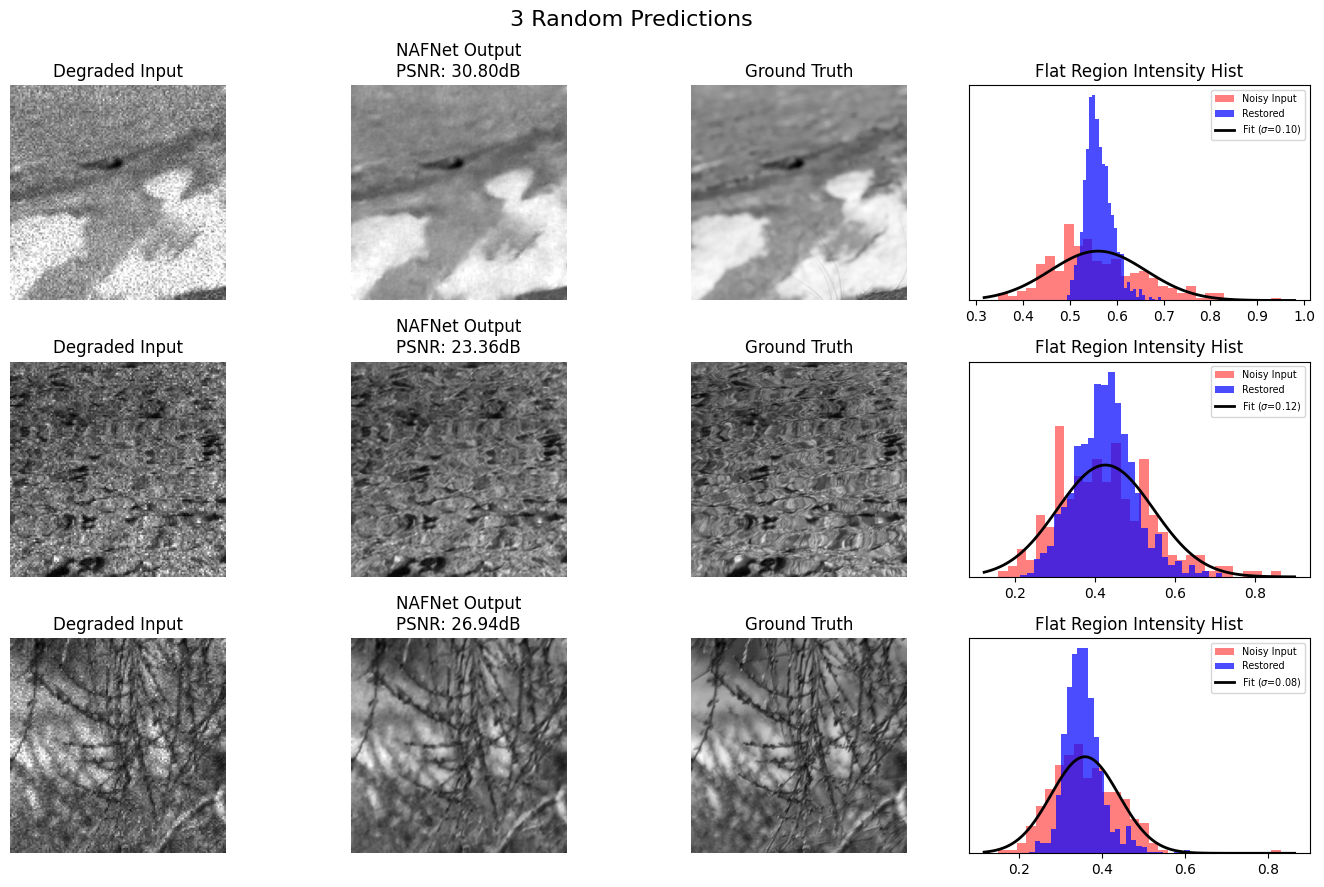

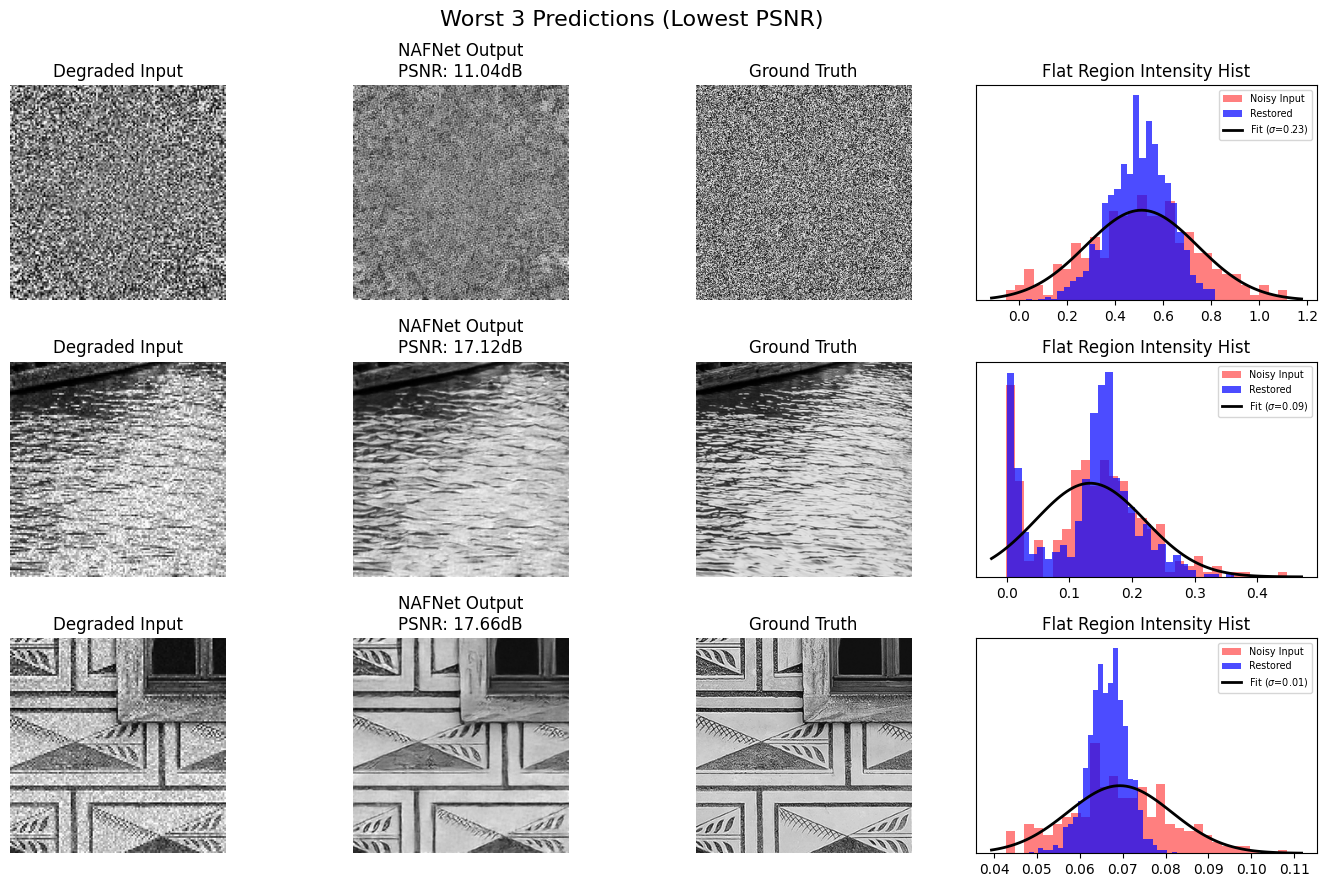

In [7]:
# Cell 6: Curves, val-PSNR distribution, and sample predictions
import scipy.stats as stats

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.plot(history['train_loss'], label='Train', color='blue')
if history.get('val_loss'): plt.plot(history['val_loss'], label='Val', color='red')
plt.title('Loss History'); plt.xlabel('Epochs'); plt.legend()
plt.subplot(1, 3, 2)
plt.plot(history['val_psnr'], label='Val PSNR', color='orange')
plt.title('Validation PSNR'); plt.xlabel('Epochs'); plt.legend()
plt.subplot(1, 3, 3)
plt.plot(history['val_ssim'], label='Val SSIM', color='green')
plt.title('Validation SSIM'); plt.xlabel('Epochs'); plt.legend()
plt.tight_layout(); plt.show()

def get_flat_patch_coords(img, size=32):
    h, w = img.shape
    if h < size or w < size: return 0, 0
    min_var = float('inf'); br = bc = 0; step = max(1, size//2)
    for r in range(0, h-size+1, step):
        for c in range(0, w-size+1, step):
            v = np.var(img[r:r+size, c:c+size])
            if v < min_var: min_var, br, bc = v, r, c
    return br, bc

model.eval(); results = []
with torch.no_grad():
    for noisy, gt in val_loader:
        pred = torch.clamp(model(noisy.to(device).float()), 0, 1)
        p = psnr_calc(pred, gt.to(device).float()).item()
        results.append({'psnr': p, 'noisy': noisy.squeeze().cpu().numpy(),
                        'pred': pred.squeeze().cpu().numpy(), 'gt': gt.squeeze().cpu().numpy()})
results.sort(key=lambda x: x['psnr'])

# ---- Val PSNR distribution: is the low tail just unrecoverable dissimilar images? ----
psnrs = np.array([r['psnr'] for r in results])
plt.figure(figsize=(7, 3))
plt.hist(psnrs, bins=30, color='steelblue', alpha=0.8)
plt.axvline(psnrs.mean(), color='red', linestyle='--', label=f'mean {psnrs.mean():.2f} dB')
plt.axvline(np.median(psnrs), color='green', linestyle='--', label=f'median {np.median(psnrs):.2f} dB')
plt.title('Per-image Val PSNR distribution'); plt.xlabel('PSNR (dB)'); plt.legend()
plt.tight_layout(); plt.show()
print(f"PSNR: mean {psnrs.mean():.2f} | median {np.median(psnrs):.2f} | "
      f"p10 {np.percentile(psnrs,10):.2f} | p90 {np.percentile(psnrs,90):.2f}")

worst_3 = results[:3]; best_3 = results[-3:][::-1]
middle = results[3:-3] if len(results) > 6 else results
random_3 = random.sample(middle, min(3, len(middle)))

def plot_samples(samples, title):
    fig, axes = plt.subplots(len(samples), 4, figsize=(14, 3*len(samples)))
    if len(samples) == 1: axes = axes[None, :]
    fig.suptitle(title, fontsize=16)
    for i, s in enumerate(samples):
        ni, pi, gi = s['noisy'], s['pred'], s['gt']
        axes[i,0].imshow(ni, cmap='gray', vmin=0, vmax=1); axes[i,0].set_title("Degraded Input"); axes[i,0].axis('off')
        axes[i,1].imshow(pi, cmap='gray', vmin=0, vmax=1); axes[i,1].set_title(f"NAFNet Output\nPSNR: {s['psnr']:.2f}dB"); axes[i,1].axis('off')
        axes[i,2].imshow(gi, cmap='gray', vmin=0, vmax=1); axes[i,2].set_title("Ground Truth"); axes[i,2].axis('off')
        ps = 32; r, c = get_flat_patch_coords(gi, ps)
        sc = gi.shape[0] // ni.shape[0] if ni.shape[0] else 1
        lr_r, lr_c, lr_sz = r//sc, c//sc, max(1, ps//sc)
        pp = pi[r:r+ps, c:c+ps].flatten(); npp = ni[lr_r:lr_r+lr_sz, lr_c:lr_c+lr_sz].flatten()
        axes[i,3].hist(npp, bins=30, alpha=0.5, color='red', density=True, label='Noisy Input')
        axes[i,3].hist(pp, bins=30, alpha=0.7, color='blue', density=True, label='Restored')
        mu, sd = np.mean(npp), np.std(npp); xmin, xmax = axes[i,3].get_xlim()
        xs = np.linspace(xmin, xmax, 100)
        axes[i,3].plot(xs, stats.norm.pdf(xs, mu, sd), 'k', lw=2, label=f'Fit ($\\sigma$={sd:.2f})')
        axes[i,3].set_title("Flat Region Intensity Hist"); axes[i,3].legend(fontsize='x-small'); axes[i,3].set_yticks([])
    plt.tight_layout(); plt.show()

plot_samples(best_3, "Best 3 Predictions (Highest PSNR)")
if random_3: plot_samples(random_3, "3 Random Predictions")
plot_samples(worst_3, "Worst 3 Predictions (Lowest PSNR)")